In [8]:
# Prognozowanie wypożyczeń rowerów

Struktura:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
None
Podstawowe statystyki:
          instant      season          yr        mnth 

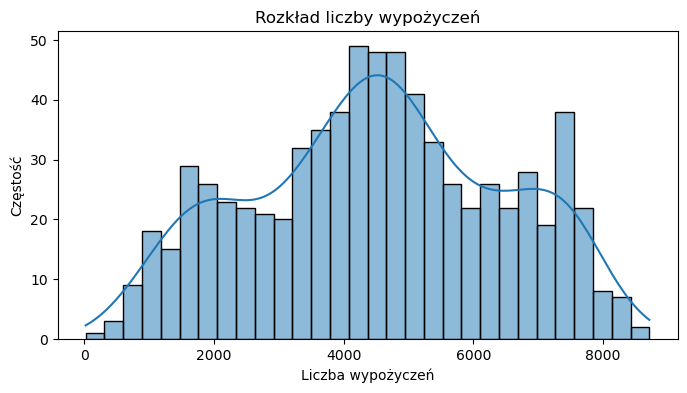

Zmienna: temp
Typ: float64
Unikalne wartości: [0.344167  0.363478  0.196364  0.2       0.226957  0.204348  0.196522
 0.165     0.138333  0.150833  0.169091  0.172727  0.16087   0.233333
 0.231667  0.175833  0.216667  0.292174  0.261667  0.1775    0.0591304
 0.0965217 0.0973913 0.223478  0.2175    0.195     0.203478  0.216522
 0.180833  0.192174  0.26      0.186957  0.211304  0.285833  0.271667
 0.220833  0.134783  0.144348  0.189091  0.2225    0.316522  0.415
 0.266087  0.318261  0.435833  0.521667  0.399167  0.285217  0.303333
 0.182222  0.221739  0.295652  0.364348  0.2825    0.343478  0.407273
 0.266667  0.335     0.198333  0.384167  0.376522  0.261739  0.2925
 0.295833  0.389091  0.329167  0.384348  0.325217  0.317391  0.365217
 0.54      0.4725    0.3325    0.430435  0.441667  0.346957  0.285
 0.264167  0.265833  0.253043  0.264348  0.3025    0.3       0.268333
 0.315     0.378333  0.573333  0.414167  0.390833  0.4375    0.335833
 0.3425    0.426667  0.595652  0.5025    0.4125    

In [56]:
# 1. Wczytanie i eksploracja danych

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("day.csv")

print("Struktura:")
print(df.info())

print("Podstawowe statystyki:")
print(df.describe())

print("\n Dyplikaty", df.duplicated().sum())
print("Braki danych\n", df.isnull().sum())

print("Mean:", df['cnt'].mean())
print("Median:", df['cnt'].median())
print("Std:", df['cnt'].std())
print("Min:", df['cnt'].min())
print("Max:", df['cnt'].max())

plt.figure(figsize=(8, 4))
sns.histplot(df['cnt'], bins=30, kde=True)
plt.title("Rozkład liczby wypożyczeń")
plt.xlabel("Liczba wypożyczeń")
plt.ylabel("Częstość")
plt.show()

features = ['temp', 'atemp', 'hum', 'windspeed', 'weekday', 'season', 'workingday', 'holiday']

for col in features:
    print(f"Zmienna: {col}")
    print("Typ:", df[col].dtype)
    print("Unikalne wartości:", df[col].unique())
    print(df[col].describe())

In [11]:
# 2. Analiza eksploracyjna (EDA)

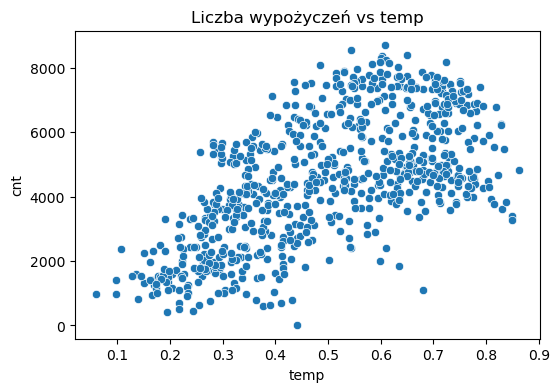

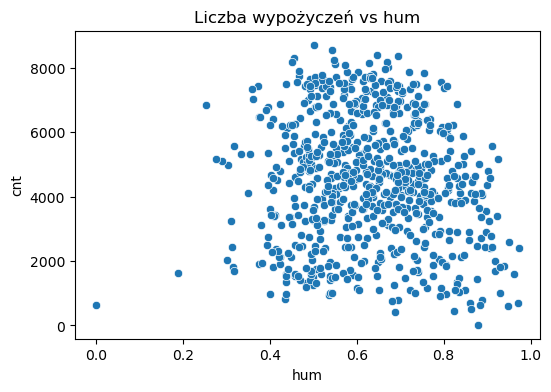

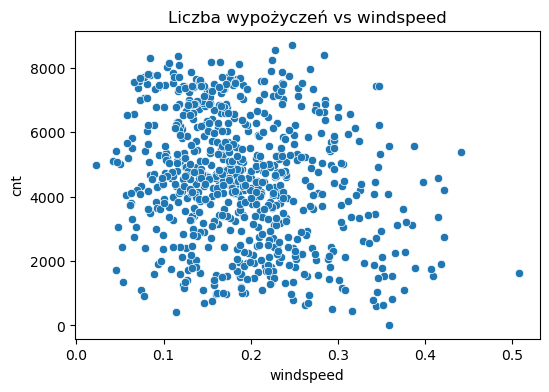

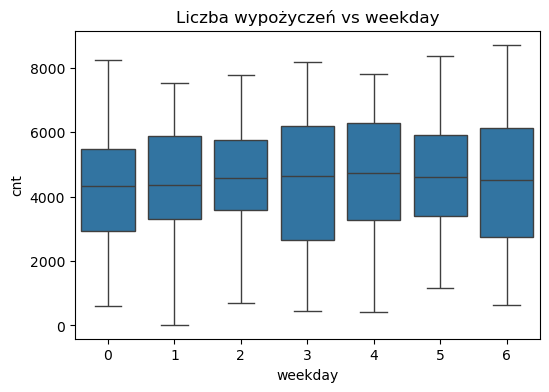

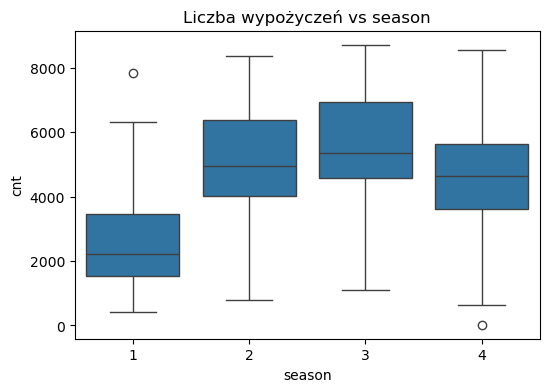

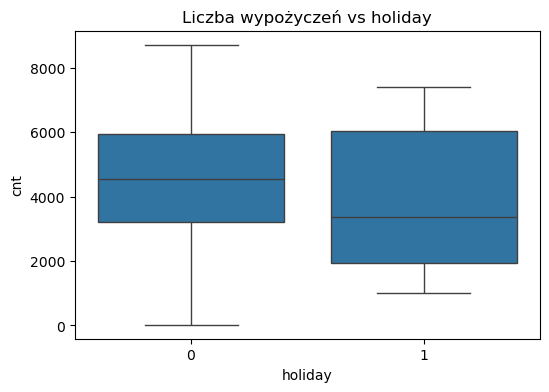

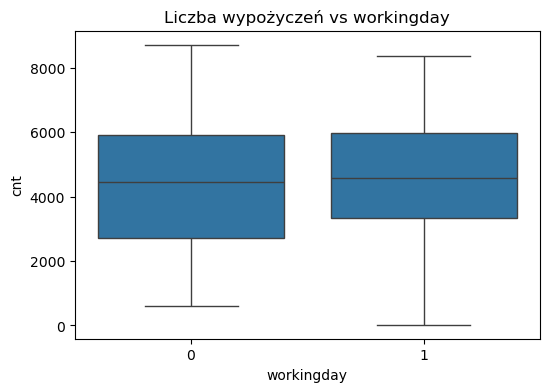

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

quant_features = ['temp', 'hum', 'windspeed']
for col in quant_features:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x=col, y='cnt')
    plt.title(f'Liczba wypożyczeń vs {col}')
    plt.show()

cat_features = ['weekday', 'season', 'holiday', 'workingday']
for col in cat_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x=col, y='cnt')
    plt.title(f'Liczba wypożyczeń vs {col}')
    plt.show()

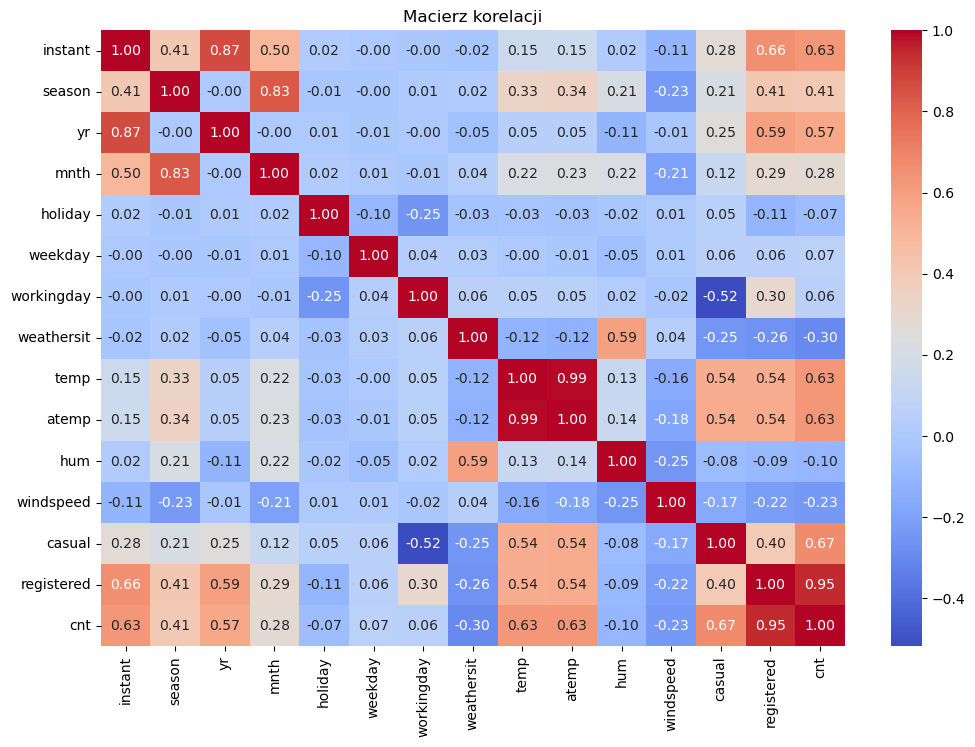

In [13]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Macierz korelacji")
plt.show()

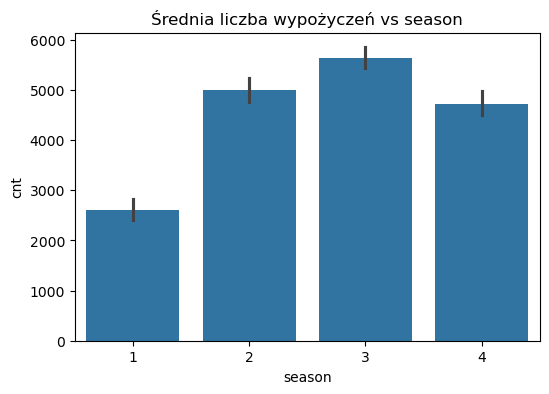

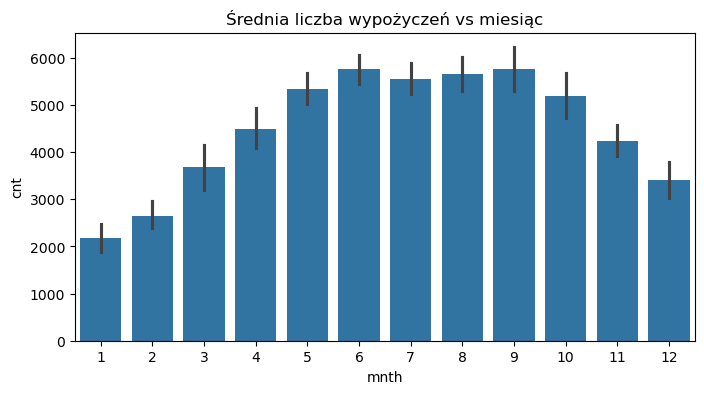

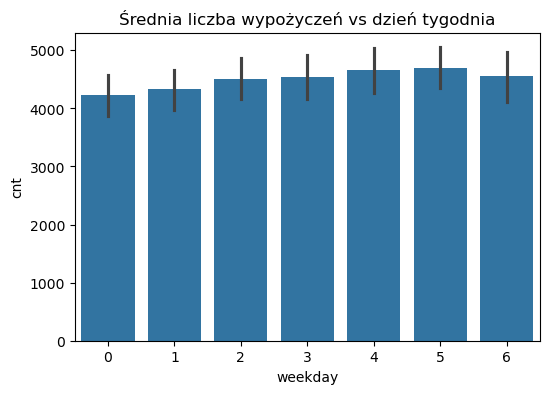

In [14]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='season', y='cnt', estimator='mean')
plt.title("Średnia liczba wypożyczeń vs season")
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(data=df, x='mnth', y='cnt', estimator='mean')
plt.title("Średnia liczba wypożyczeń vs miesiąc")
plt.show()

plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='weekday', y='cnt', estimator='mean')
plt.title("Średnia liczba wypożyczeń vs dzień tygodnia")
plt.show()

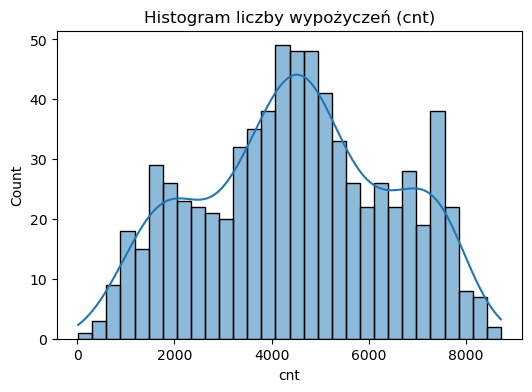

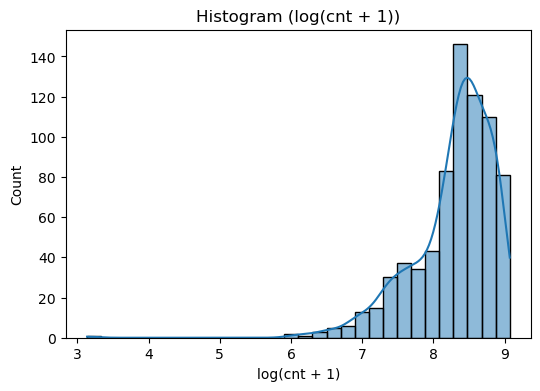

In [15]:
plt.figure(figsize=(6, 4))
sns.histplot(df['cnt'], bins=30, kde=True)
plt.title("Histogram liczby wypożyczeń (cnt)")
plt.xlabel("cnt")
plt.show()

import numpy as np

df['cnt_log'] = np.log1p(df['cnt'])

plt.figure(figsize=(6, 4))
sns.histplot(df['cnt_log'], bins=30, kde=True)
plt.title("Histogram (log(cnt + 1))")
plt.xlabel("log(cnt + 1)")
plt.show()

In [17]:
# Nie ma potrzeby stosowania logarytmicznej transformacji zmiennej cnt. 
# Oryginalny rozkład jest wystarczająco symetryczny dla modeli regresyjnych, a transformacja tylko go spłaszcza i skupia.

In [19]:
# 3. Przygotowanie danych

In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df_model = df.drop(columns=['instant', 'dteday', 'casual', 'registered', 'cnt_log'])

X = df_model.drop(columns=['cnt'])
y = df_model['cnt']

categorical_cols = ['season', 'weathersit', 'weekday', 'mnth', 'holiday', 'workingday', 'yr']
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

numeric_cols = ['temp', 'atemp', 'hum', 'windspeed']
scaler = StandardScaler()
X_encoded[numeric_cols] = scaler.fit_transform(X_encoded[numeric_cols])

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (584, 29)
X_test: (147, 29)


In [37]:
# 4. Budowa modeli regresyjnych

In [30]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

In [31]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [32]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

Ridge()

In [33]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

Lasso(alpha=0.1)

In [34]:
tree = DecisionTreeRegressor(max_depth=6, random_state=42)
tree.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=6, random_state=42)

In [35]:
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, random_state=42)

In [36]:
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
gb.fit(X_train, y_train)

GradientBoostingRegressor(max_depth=4, random_state=42)

In [38]:
# 5. Ocena modeli

In [40]:
models = {
    "Linear Regression": lr,
    "Ridge Regression": ridge,
    "Lasso Regression": lasso,
    "Decision Tree": tree,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

results = []

for name, model in models.items():
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    row = {
        "Model": name,
        "Train MAE": mean_absolute_error(y_train, y_train_pred),
        "Train MSE": mean_squared_error(y_train, y_train_pred),
        "Train RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "Train R2": r2_score(y_train, y_train_pred),
        "Test MAE": mean_absolute_error(y_test, y_test_pred),
        "Test MSE": mean_squared_error(y_test, y_test_pred),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred)),
        "Test R2": r2_score(y_test, y_test_pred)
    }
    results.append(row)

metrics_df = pd.DataFrame(results)
metrics_df = metrics_df.round(2)
print(metrics_df.to_string(index=False))

            Model  Train MAE  Train MSE  Train RMSE  Train R2  Test MAE  Test MSE  Test RMSE  Test R2
Linear Regression     548.18  561395.12      749.26      0.85    583.02 634351.36     796.46     0.84
 Ridge Regression     551.12  562629.91      750.09      0.85    586.51 638860.94     799.29     0.84
 Lasso Regression     548.40  561407.54      749.27      0.85    583.49 634965.96     796.85     0.84
    Decision Tree     404.27  314743.78      561.02      0.91    660.81 966371.23     983.04     0.76
    Random Forest     238.78  102648.99      320.39      0.97    489.02 538438.94     733.78     0.87
Gradient Boosting     217.18   82070.27      286.48      0.98    472.90 451117.79     671.65     0.89


In [41]:
# Brak niedoszacowania dla modeli, występuje za to silne przeuczenie dla drzew decyzyjnych. Najlepsze wyniki daje Gradient Boosting.

In [42]:
# 6. Interpretacja modelu

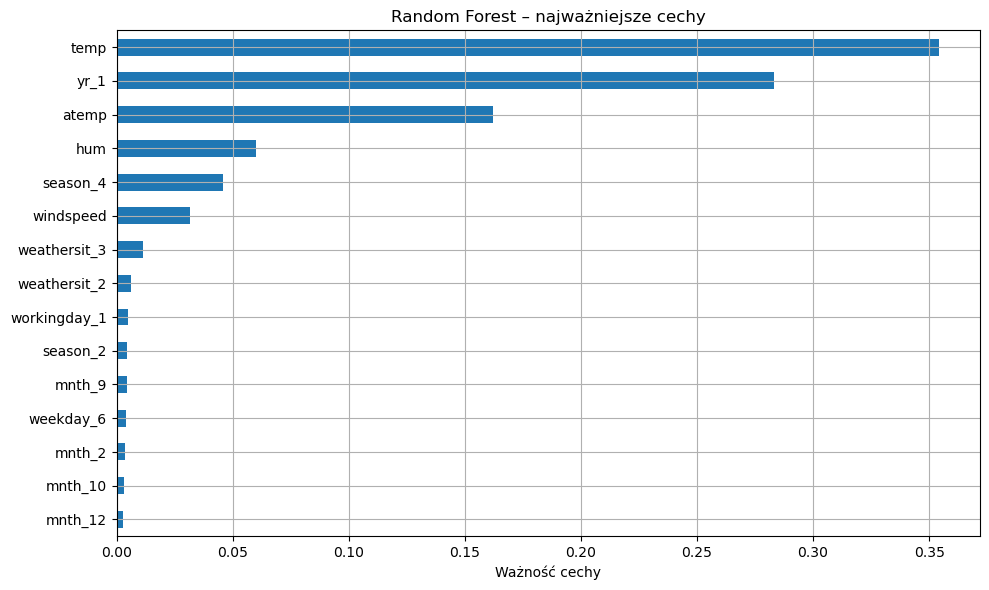

In [43]:
importances_rf = pd.Series(rf.feature_importances_, index=X_train.columns)
importances_rf = importances_rf.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances_rf.head(15).plot(kind='barh')
plt.title("Random Forest – najważniejsze cechy")
plt.xlabel("Ważność cechy")
plt.gca().invert_yaxis()
plt.grid(True)
plt.tight_layout()
plt.show()

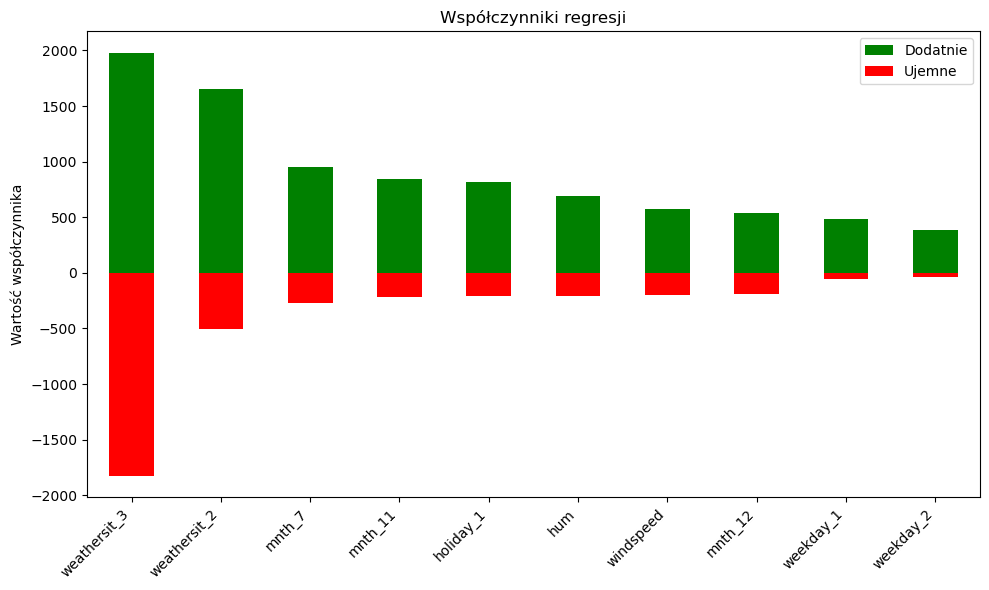

In [44]:
coefs_lr = pd.Series(lr.coef_, index=X_train.columns)

coefs_pos = coefs_lr[coefs_lr > 0].sort_values(ascending=False)
coefs_neg = coefs_lr[coefs_lr < 0].sort_values()

plt.figure(figsize=(10, 6))
coefs_pos.head(10).plot(kind='bar', color='green', label='Dodatnie')
coefs_neg.head(10).plot(kind='bar', color='red', label='Ujemne')
plt.title("Współczynniki regresji")
plt.ylabel("Wartość współczynnika")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

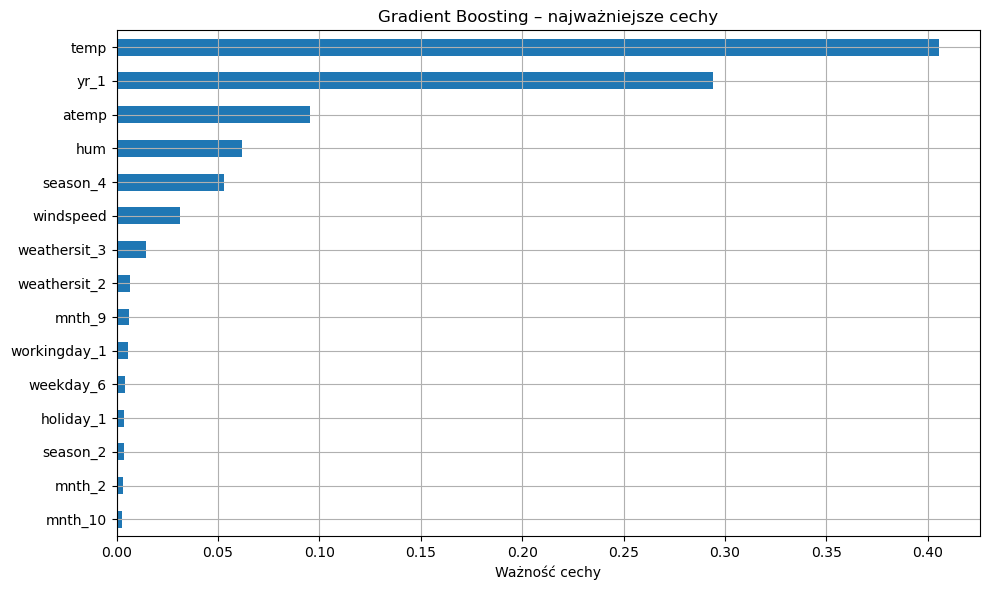

In [46]:
importances_gb = pd.Series(gb.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances_gb.head(15).plot(kind='barh')
plt.title("Gradient Boosting – najważniejsze cechy")
plt.xlabel("Ważność cechy")
plt.gca().invert_yaxis()
plt.grid(True)
plt.tight_layout()
plt.show()importances_tree = pd.Series(tree.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances_tree.head(15).plot(kind='barh')
plt.title("Decision Tree – najważniejsze cechy")
plt.xlabel("Ważność cechy")
plt.gca().invert_yaxis()
plt.grid(True)
plt.tight_layout()
plt.show()

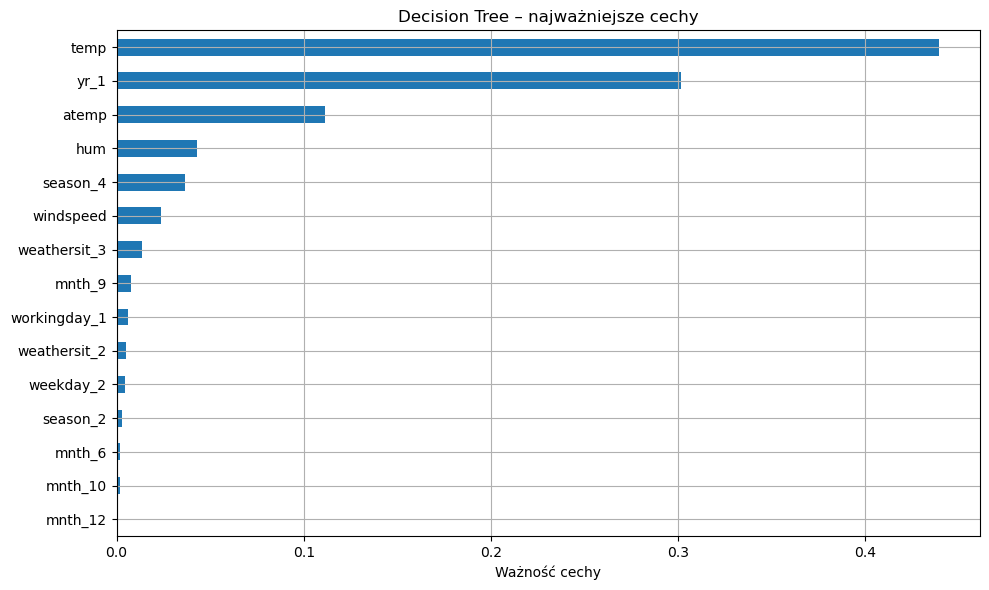

In [47]:
importances_tree = pd.Series(tree.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances_tree.head(15).plot(kind='barh')
plt.title("Decision Tree – najważniejsze cechy")
plt.xlabel("Ważność cechy")
plt.gca().invert_yaxis()
plt.grid(True)
plt.tight_layout()
plt.show()

In [57]:
# Top 3 cechy dla random forest to: temp (0.35), yr_1(0.27), atemp(0.16), czwarty wunik ma 0.06
# Top 3 cechy dla linear regression: weathersit_3 (dużo dodatnich i ujemnych), weathersit_2 (80% dodatnich, 20% ujemnych), mnth_7 (również 80%/20%)

# Czy modele wskazują te same cechy?
# Nie wszystkie. Modele zespołowe (Random Forest) wskazują: Cechy ciągłe i silnie korelujące (temp, atemp), Globalne trendy (yr_1).
# Modele liniowe wskazują: iKategoryczne zmienne o silnych (ale prostych) relacjach.

# Najbardziej wpływowe cechy według modeli zespołowych (RF, GB, DT):
    #temp: im cieplej, tym więcej wypożyczeń (do pewnego momentu).
    #atemp: odczuwalna temperatura jako uzupełnienie temp.
    #yr_1: rok 2012 - więcej wypożyczeń niż w 2011 (efekt wzrostu popularności).

#Modele proste (regresja liniowa) wskazują inne cechy (weathersit, mnth_7) ze względu na uproszczone założenia i brak obsługi nieliniowości.

In [51]:
# 7. Wnioski

In [52]:
# Porównano sześć modeli regresyjnych. Najlepsze wyniki na zbiorze testowym uzyskał Gradient Boosting Regressor, który osiągnął:
    # R^2 = 0.89 – bardzo wysokie dopasowanie,
    # RMSE = 672 – najniższy błąd spośród wszystkich modeli,
    # MAE = 473 – również najniższy średni błąd bezwzględny.

# Drugie miejsce zajął Random Forest (R² = 0.87), natomiast Regresja Liniowa, Ridge i Lasso osiągnęły zbliżone, ale nieco niższe wyniki (R² ≈ 0.84). 
#Decision Tree miało istotnie słabsze dopasowanie (R² = 0.76), z wyraźnym przeuczeniem.

In [53]:
# Zastosowane metody preprocessingowe miały istotny wpływ na jakość predykcji:
    # One-hot encoding zmiennych kategorycznych umożliwił ich skuteczne wykorzystanie w modelach liniowych i drzewiastych.
    # Skalowanie zmiennych numerycznych (StandardScaler) było szczególnie istotne dla modeli opartych na gradientach.
    # Transformacja logarytmiczna zmiennej celu nie była potrzebna – oryginalny rozkład cnt był wystarczająco symetryczny.
#Dzięki preprocessingowi modele zespołowe mogły łatwiej wyodrębnić najważniejsze wzorce.

In [58]:
#Najważniejsze zmienne wg modeli zespołowych (RF, GB, DT):
    # temp - Wyższa temperatura sprzyja większej liczbie wypożyczeń (do pewnego momentu)
    # atemp - Odczuwalna temperatura – uzupełnia temp, bardziej subiektywna miara
    # vyr_1 - W roku 2012 system wypożyczeń był bardziej rozwinięty niż w 2011
# Modele proste (Linear Regression) wskazywały inne zmienne (weathersit_3, mnth_7), co wynika z ich liniowego charakteru i braku interakcji między cechami.

In [59]:
# Ulepszenia modelu
# Dane:
    # Dane godzinowe: model mógłby lepiej przewidywać wzorce szczytowe, sezonowe (pory roku) jak i dzienne (rano, wieczorem).
    # Lepsze dane pogodowe: dokładniejsze pomiary (np. temperatura).
    # Czynniki zewnętrzne: koncerty, protesty, dni wolne.
    # Dane przestrzenne: informacje o lokalizacji stacji, ich popularności, typie terenu.

# Modele:
    # MLP (Keras) – sieci neuronowe mogłyby wykrywać bardziej złożone wzorce.
    # XGBoost / LightGBM – bardziej zaawansowane boostery z automatycznym tuningiem.
    # Stacking / Ensemble – połączenie kilku modeli może dodatkowo poprawić wyniki.